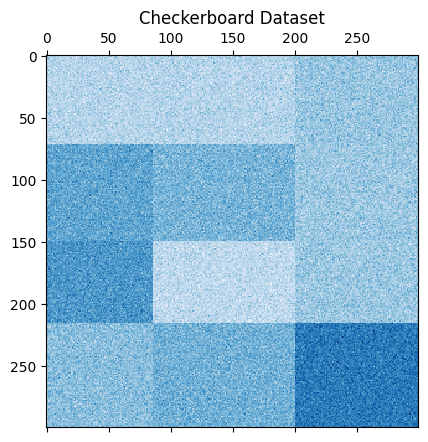

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_checkerboard
#making a checkerboard datasets 

n_clusters = (4,3)
data,rows,columns = make_checkerboard(
    shape=(300,300), n_clusters=n_clusters, noise=10, shuffle=False, random_state=42
)
plt.matshow(data, cmap= plt.cm.Blues)
plt.title("Checkerboard Dataset")
plt.show()

now we shuffle the data and the goal is to reconstruct it after using spectralbiclustering

In [ ]:
import numpy as np
# creating the list of shuffled indices for rows and columns
rng = np.random.RandomState(0)
row_idx_shuffled = rng.permutation(data.shape[0])
col_idx_shuffled = rng.permutation(data.shape[1])

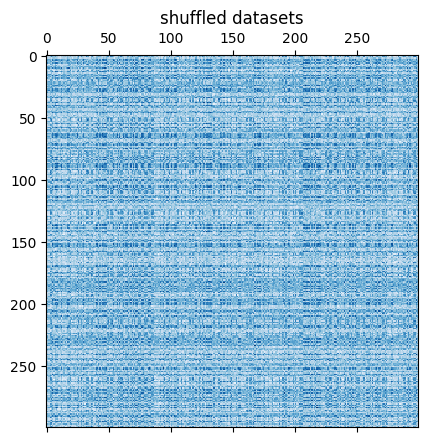

In [4]:
data =  data[row_idx_shuffled][:, col_idx_shuffled]
plt.matshow(data, cmap = plt.cm.Blues)
plt.title("shuffled datasets")
plt.show()

In [9]:
#fitting the biclustering model
from sklearn.cluster import SpectralBiclustering
from sklearn.metrics import consensus_score
model = SpectralBiclustering(n_clusters=n_clusters, method='log',random_state=42)
model.fit(data)
#computing the similarity of two sets of biclusters
score = consensus_score(
    model.biclusters_,(rows[:, row_idx_shuffled], columns[:, col_idx_shuffled])
)
print(f"consensus score : {score:.1f}")

consensus score : 1.0


Plotting results

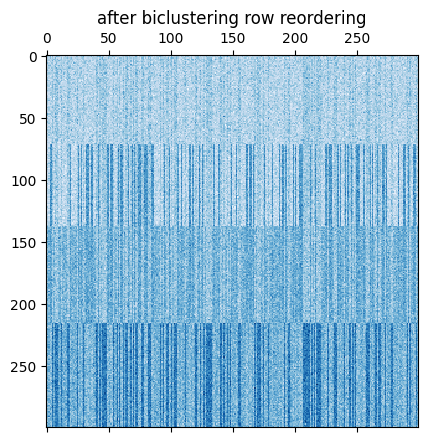

In [10]:
#reordering first the rows and then the columns

recorded_rows = data[np.argsort(model.row_labels_)]
reordered_data = recorded_rows[:,np.argsort(model.column_labels_)]

plt.matshow(recorded_rows,cmap = plt.cm.Blues)
plt.title('after biclustering row reordering')
plt.show()

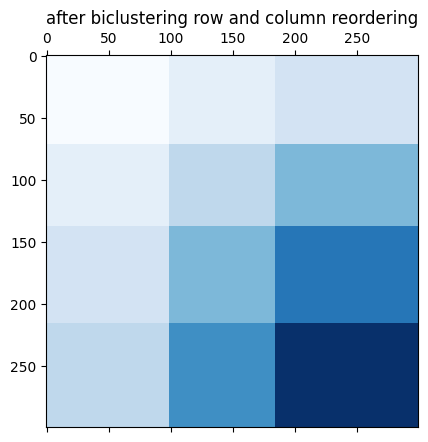

In [11]:
plt.matshow(
    np.outer(np.sort(model.row_labels_) +1,
               np.sort(model.column_labels_) +1
             ),
    cmap = plt.cm.Blues
)
plt.title("after biclustering row and column reordering")
plt.show()